## Can I predict a hit song on 

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme()
%matplotlib inline
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy import stats

Exploring a Spotify songs database. Can I model a hit song? Source: https://www.kaggle.com/datasets/joebeachcapital/30000-spotify-songs

In [2]:
spotify = pd.read_csv('data/spotify_songs.csv')

In [3]:
spotify.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [4]:
spotify.columns

Index(['track_id', 'track_name', 'track_artist', 'track_popularity',
       'track_album_id', 'track_album_name', 'track_album_release_date',
       'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'duration_ms'],
      dtype='str')

In [5]:
spotify.describe()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000
mean,42.477081,0.654850,0.698619,5.374471,-6.719499,0.565711,0.107068,0.175334,0.084747,0.190176,0.510561,120.881132,225799.811622
std,24.984074,0.145085,0.180910,3.611657,2.988436,0.495671,0.101314,0.219633,0.224230,0.154317,0.233146,26.903624,59834.006182
min,0.000000,0.000000,0.000175,0.000000,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4000.000000
25%,24.000000,0.563000,0.581000,2.000000,-8.171000,0.000000,0.041000,0.015100,0.000000,0.092700,0.331000,99.960000,187819.000000
50%,45.000000,0.672000,0.721000,6.000000,-6.166000,1.000000,0.062500,0.080400,0.000016,0.127000,0.512000,121.984000,216000.000000
75%,62.000000,0.761000,0.840000,9.000000,-4.645000,1.000000,0.132000,0.255000,0.004830,0.248000,0.693000,133.918000,253585.000000
max,100.000000,0.983000,1.000000,11.000000,1.275000,1.000000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,517810.000000


array([[<Axes: title={'center': 'track_popularity'}>,
        <Axes: title={'center': 'danceability'}>,
        <Axes: title={'center': 'energy'}>,
        <Axes: title={'center': 'key'}>],
       [<Axes: title={'center': 'loudness'}>,
        <Axes: title={'center': 'mode'}>,
        <Axes: title={'center': 'speechiness'}>,
        <Axes: title={'center': 'acousticness'}>],
       [<Axes: title={'center': 'instrumentalness'}>,
        <Axes: title={'center': 'liveness'}>,
        <Axes: title={'center': 'valence'}>,
        <Axes: title={'center': 'tempo'}>],
       [<Axes: title={'center': 'duration_ms'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

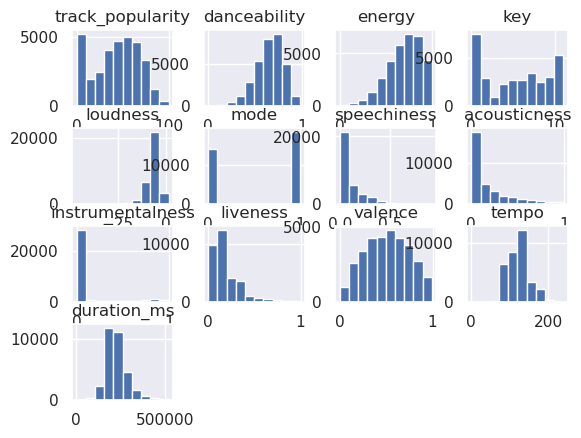

In [6]:
spotify.hist()

In [7]:
spotify.describe()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000
mean,42.477081,0.654850,0.698619,5.374471,-6.719499,0.565711,0.107068,0.175334,0.084747,0.190176,0.510561,120.881132,225799.811622
std,24.984074,0.145085,0.180910,3.611657,2.988436,0.495671,0.101314,0.219633,0.224230,0.154317,0.233146,26.903624,59834.006182
min,0.000000,0.000000,0.000175,0.000000,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4000.000000
25%,24.000000,0.563000,0.581000,2.000000,-8.171000,0.000000,0.041000,0.015100,0.000000,0.092700,0.331000,99.960000,187819.000000
50%,45.000000,0.672000,0.721000,6.000000,-6.166000,1.000000,0.062500,0.080400,0.000016,0.127000,0.512000,121.984000,216000.000000
75%,62.000000,0.761000,0.840000,9.000000,-4.645000,1.000000,0.132000,0.255000,0.004830,0.248000,0.693000,133.918000,253585.000000
max,100.000000,0.983000,1.000000,11.000000,1.275000,1.000000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,517810.000000


In [8]:
corr = spotify.corr(numeric_only=True)
corr

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
track_popularity,1.000000,0.064748,-0.109112,-0.000650,0.057687,0.010637,0.006819,0.085159,-0.149872,-0.054584,0.033231,-0.005378,-0.143682
danceability,0.064748,1.000000,-0.086073,0.011736,0.025335,-0.058647,0.181721,-0.024519,-0.008655,-0.123859,0.330523,-0.184084,-0.096879
energy,-0.109112,-0.086073,1.000000,0.010052,0.676625,-0.004800,-0.032150,-0.539745,0.033247,0.161223,0.151103,0.149951,0.012611
key,-0.000650,0.011736,0.010052,1.000000,0.000959,-0.174093,0.022607,0.004306,0.005968,0.002887,0.019914,-0.013370,0.015139
loudness,0.057687,0.025335,0.676625,0.000959,1.000000,-0.019289,0.010339,-0.361638,-0.147824,0.077613,0.053384,0.093767,-0.115058
mode,0.010637,-0.058647,-0.004800,-0.174093,-0.019289,1.000000,-0.063512,0.009415,-0.006741,-0.005549,0.002614,0.014329,0.015634
speechiness,0.006819,0.181721,-0.032150,0.022607,0.010339,-0.063512,1.000000,0.026092,-0.103424,0.055426,0.064659,0.044603,-0.089431
acousticness,0.085159,-0.024519,-0.539745,0.004306,-0.361638,0.009415,0.026092,1.000000,-0.006850,-0.077243,-0.016845,-0.112724,-0.081581
instrumentalness,-0.149872,-0.008655,0.033247,0.005968,-0.147824,-0.006741,-0.103424,-0.006850,1.000000,-0.005507,-0.175402,0.023335,0.063235
liveness,-0.054584,-0.123859,0.161223,0.002887,0.077613,-0.005549,0.055426,-0.077243,-0.005507,1.000000,-0.020560,0.021018,0.006138


In [9]:
results = smf.ols('track_popularity ~ danceability + energy + key + loudness + mode + speechiness + acousticness + instrumentalness + liveness + valence + tempo + duration_ms',data = spotify).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       track_popularity   R-squared:                       0.072
Model:                            OLS   Adj. R-squared:                  0.072
Method:                 Least Squares   F-statistic:                     212.9
Date:                Thu, 30 Apr 2026   Prob (F-statistic):               0.00
Time:                        09:13:33   Log-Likelihood:            -1.5102e+05
No. Observations:               32833   AIC:                         3.021e+05
Df Residuals:                   32820   BIC:                         3.022e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           77.8274      1.674     46.481      0.000      74.546      81.109
danceability         5.0428      1.049      4.809      0.000       2.988       7.098
energy             -29.5189      1.198    -24.642      0.000     -31.867     -27.171
key                  0.0427      0.037      1.143      0.253      -0.031       0.116
loudness             1.5247      0.064     23.764      0.000       1.399       1.650
mode                 0.7176      0.273      2.627      0.009       0.182       1.253
speechiness         -7.2535      1.356     -5.348      0.000      -9.912      -4.595
acousticness         3.2221      0.732      4.402      0.000       1.788       4.657
instrumentalness   -11.9794      0.630    -19.005      0.000     -13.215     -10.744
liveness            -4.3124      0.882     -4.890      0.000      -6.041      -2.584
valence              2.7833      0.641      4.340      0.000       1.526       4.040
tempo                0.0213      0.005      4.171      0.000       0.011       0.031
duration_ms      -4.592e-05   2.28e-06    -20.170      0.000   -5.04e-05   -4.15e-05
==============================================================================
Omnibus:                     3799.122   Durbin-Watson:                   1.178
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1419.195
Skew:                          -0.289   Prob(JB):                    6.69e-309
Kurtosis:                       2.161   Cond. No.                     3.58e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.58e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

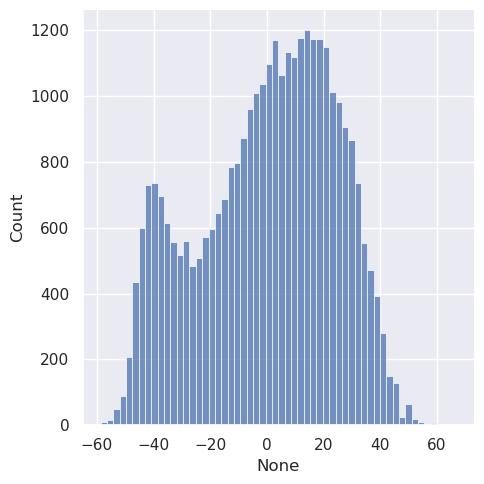

In [10]:
sns.displot(x=results.resid)

In [11]:
results = smf.ols('track_popularity ~ danceability + energy + key + loudness + mode + speechiness + acousticness + instrumentalness + liveness + valence + tempo + duration_ms',data = spotify).fit_regularized()
results.params

Intercept           57.497818
danceability         6.867472
energy             -21.567406
key                  0.095799
loudness             1.123025
mode                 1.183389
speechiness         -5.345878
acousticness         6.543464
instrumentalness   -12.618947
liveness            -3.144802
valence              4.081272
tempo                0.064768
duration_ms         -0.000032
dtype: float64

In [12]:
np.sqrt(np.mean((spotify['track_popularity'] - results.fittedvalues)**2))

np.float64(24.142424058034358)

This model seems to be the best bet.

In [13]:
results = smf.ols('track_popularity ~ danceability + energy + key + loudness + mode + speechiness + acousticness + instrumentalness + liveness + valence + tempo + duration_ms',data = spotify).fit_regularized(alpha=.01)
results.params

Intercept           56.886569
danceability         6.488306
energy             -20.511705
key                  0.094436
loudness             1.081348
mode                 1.204508
speechiness          0.000000
acousticness         6.438810
instrumentalness   -12.357650
liveness            -3.167473
valence              3.665010
tempo                0.061011
duration_ms         -0.000032
dtype: float64

In [14]:
np.sqrt(np.mean((spotify['track_popularity'] - results.fittedvalues)**2))

np.float64(24.15207727236166)

In [15]:
results = smf.ols('track_popularity ~ danceability + energy + key + loudness + mode + speechiness + acousticness + instrumentalness + liveness + valence + tempo + duration_ms',data = spotify).fit_regularized(alpha=.02)
results.params

Intercept           56.448032
danceability         6.521046
energy             -19.804823
key                  0.093836
loudness             1.050313
mode                 1.163213
speechiness          0.000000
acousticness         6.385072
instrumentalness   -12.277208
liveness            -2.846941
valence              3.413525
tempo                0.060105
duration_ms         -0.000032
dtype: float64

In [16]:
results = smf.ols('track_popularity ~ danceability + energy + key + loudness + mode + speechiness + acousticness + instrumentalness + liveness + valence + tempo + duration_ms',data = spotify).fit_regularized(alpha=0.5)
results.params

Intercept           38.806126
danceability         3.083354
energy               0.000000
key                  0.168539
loudness             0.000000
mode                 0.000000
speechiness          0.000000
acousticness         1.221540
instrumentalness    -5.561386
liveness             0.000000
valence              0.000000
tempo                0.068846
duration_ms         -0.000034
dtype: float64

In [17]:
np.sqrt(np.mean((spotify['track_popularity'] - results.fittedvalues)**2))

np.float64(24.659194297249947)

In [18]:
np.mean((spotify['track_popularity'] - results.fittedvalues)**2)

np.float64(608.0758633895242)

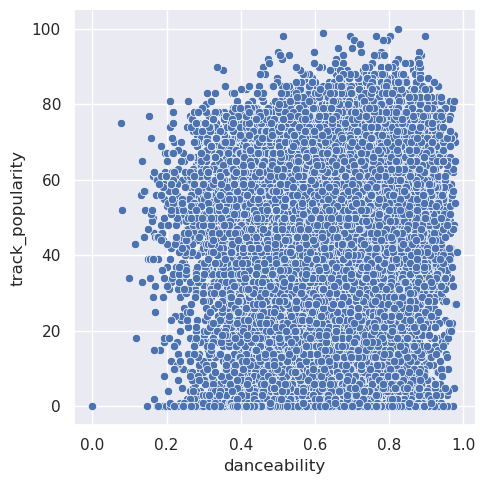

In [20]:
sns.relplot(x='danceability',y='track_popularity',data=spotify)

Danceability might be a significant contributor, based on the p and t values.

In [21]:
danceable_lm = smf.ols('track_popularity ~ danceability',data=spotify).fit()
danceable_lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       track_popularity   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     138.2
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           7.57e-32
Time:                        09:15:00   Log-Likelihood:            -1.5218e+05
No. Observations:               32833   AIC:                         3.044e+05
Df Residuals:                   32831   BIC:                         3.044e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       35.1757      0.636     55.298      0.000      33.929      36.422
danceability    11.1497      0.948     11.757      0.000       9.291      13.009
==============================================================================
Omnibus:                     5647.007   Durbin-Watson:                   1.058
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1501.463
Skew:                          -0.237   Prob(JB):                         0.00
Kurtosis:                       2.066   Cond. No.                         9.89
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [22]:
danceable_lm = smf.ols('track_popularity ~ danceability',data=spotify).fit()
danceable_lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       track_popularity   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     138.2
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           7.57e-32
Time:                        09:15:01   Log-Likelihood:            -1.5218e+05
No. Observations:               32833   AIC:                         3.044e+05
Df Residuals:                   32831   BIC:                         3.044e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       35.1757      0.636     55.298      0.000      33.929      36.422
danceability    11.1497      0.948     11.757      0.000       9.291      13.009
==============================================================================
Omnibus:                     5647.007   Durbin-Watson:                   1.058
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1501.463
Skew:                          -0.237   Prob(JB):                         0.00
Kurtosis:                       2.066   Cond. No.                         9.89
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

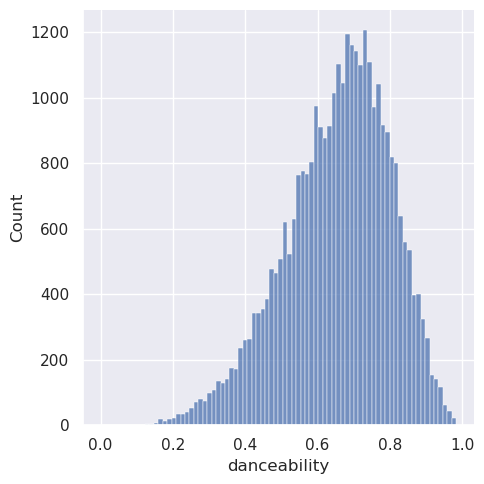

In [23]:
sns.displot(x='danceability',data=spotify)

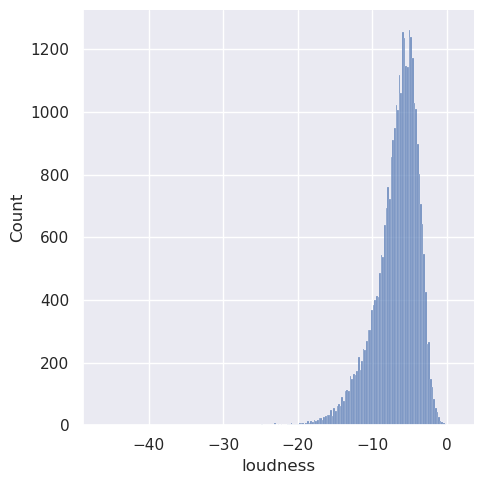

In [24]:
sns.displot(x='loudness',data=spotify)

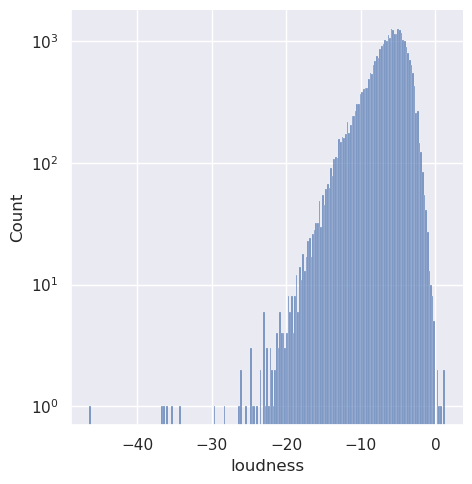

In [25]:
sns.displot(x='loudness',data=spotify)
plt.yscale("log")

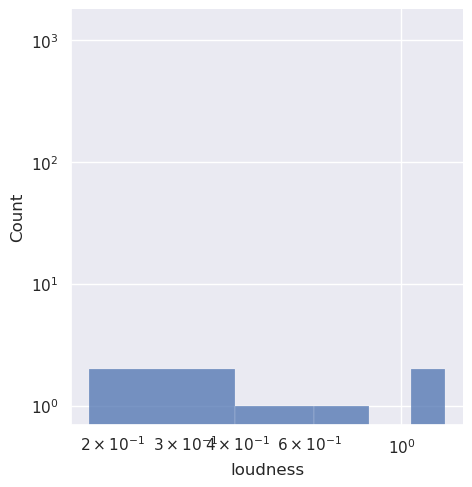

In [26]:
sns.displot(x='loudness',data=spotify)
plt.yscale("log")
plt.xscale("log")

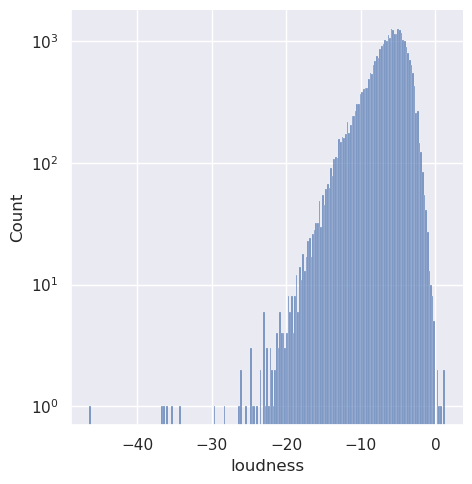

In [27]:
sns.displot(x='loudness',data=spotify)
plt.yscale("log")

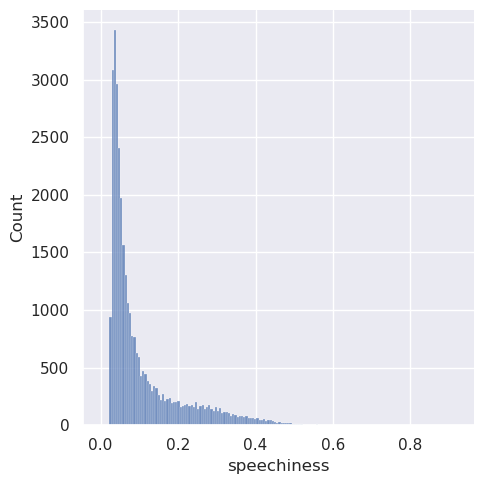

In [28]:
sns.displot(x='speechiness',data=spotify)

Let's look at the log scale, since it seems pretty skewed.

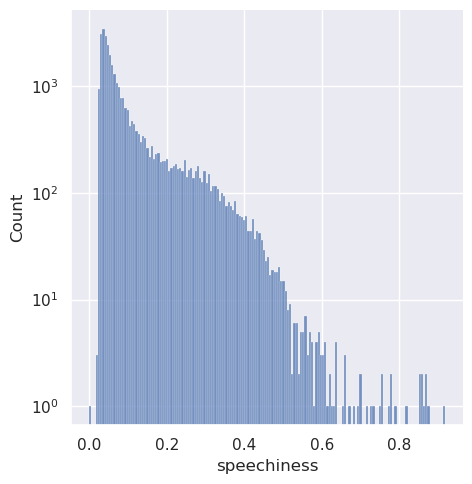

In [29]:
sns.displot(x='speechiness',data=spotify)
plt.yscale("log")

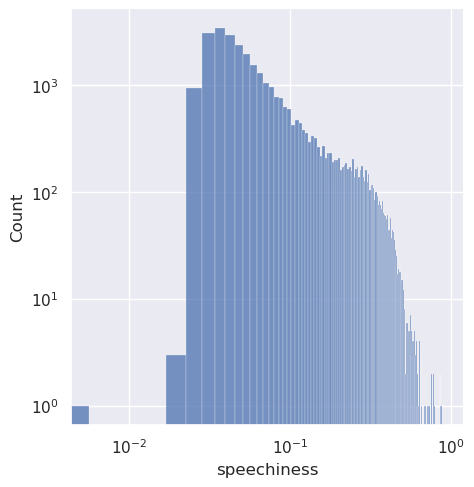

In [30]:
sns.displot(x='speechiness',data=spotify)
plt.yscale("log")
plt.xscale("log")

I think this goes to show that engineering a hit song is a lot harder than it sounds. It might just be more of an art than a science. It's still interesting to observe the behavior of skewed distributions when the log is taken of them.

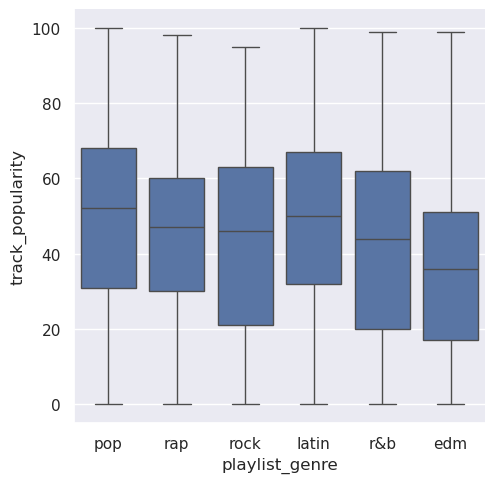

In [31]:
sns.catplot(x='playlist_genre',y='track_popularity',kind='box',data=spotify)

In [32]:
genre_lm = smf.ols('track_popularity ~ C(playlist_genre)',data=spotify).fit()

In [33]:
genre_lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       track_popularity   R-squared:                       0.031
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     207.2
Date:                Thu, 30 Apr 2026   Prob (F-statistic):          2.70e-218
Time:                        09:15:08   Log-Likelihood:            -1.5174e+05
No. Observations:               32833   AIC:                         3.035e+05
Df Residuals:                   32827   BIC:                         3.035e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                     34.8335      0.316    110.071      0.000      34.213      35.454
C(playlist_genre)[T.latin]    12.1930      0.466     26.142      0.000      11.279      13.107
C(playlist_genre)[T.pop]      12.9113      0.458     28.172      0.000      12.013      13.810
C(playlist_genre)[T.r&b]       6.3900      0.460     13.892      0.000       5.488       7.292
C(playlist_genre)[T.rap]       8.3819      0.453     18.491      0.000       7.493       9.270
C(playlist_genre)[T.rock]      6.8948      0.472     14.621      0.000       5.971       7.819
==============================================================================
Omnibus:                     3932.149   Durbin-Watson:                   1.087
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1381.556
Skew:                          -0.267   Prob(JB):                    9.97e-301
Kurtosis:                       2.149   Cond. No.                         6.56
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

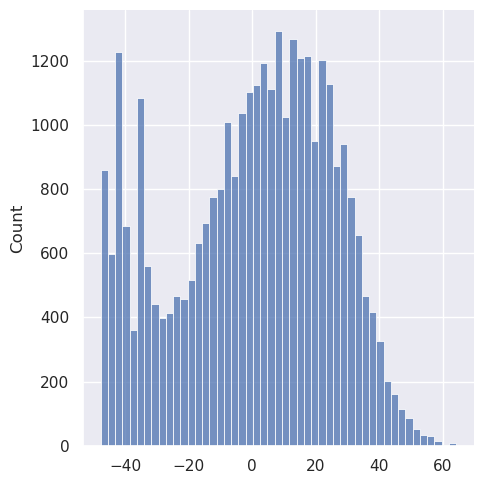

In [34]:
sns.displot(genre_lm.resid)

In [35]:
sm.stats.anova_lm(genre_lm)

,df,sum_sq,mean_sq,F,PR(>F)
C(playlist_genre),5.0,6.270131e+05,125402.611938,207.209051,2.702657e-218
Residual,32827.0,1.986685e+07,605.198524,NaN,NaN


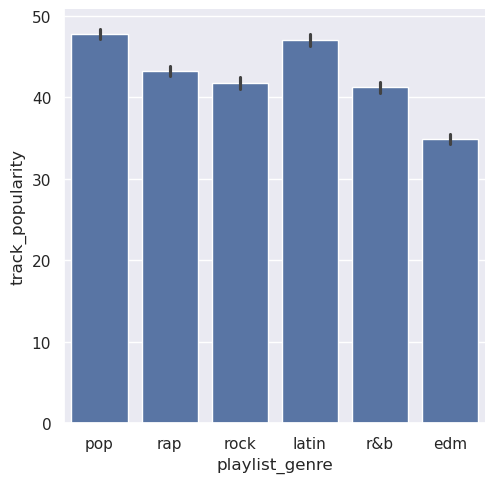

In [36]:
sns.catplot(x='playlist_genre',y='track_popularity',kind='bar',data=spotify)

Genre is a significant predictor of popularity.

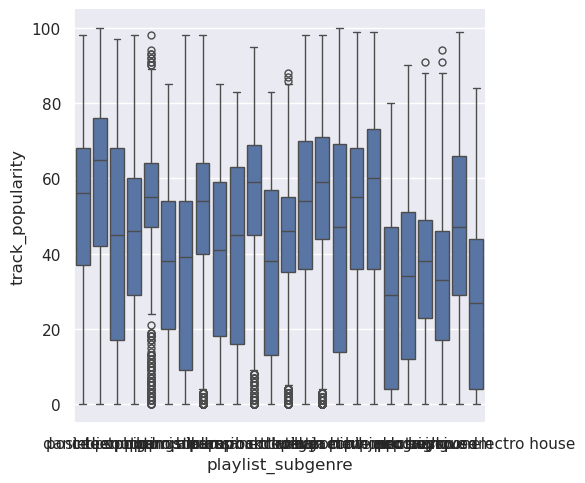

In [37]:
sns.catplot(x='playlist_subgenre',y='track_popularity',kind='box',data=spotify)

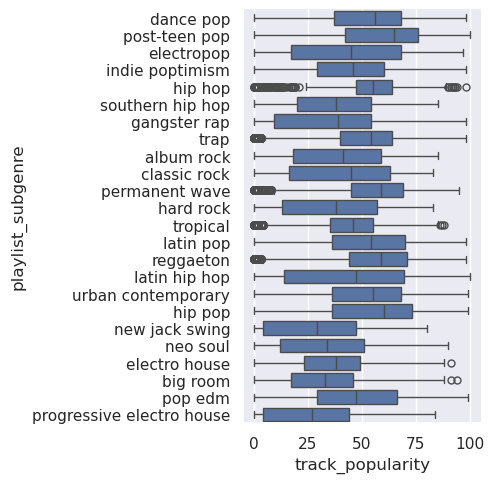

In [38]:
sns.catplot(y='playlist_subgenre',x='track_popularity',kind='box',data=spotify)

In [39]:
subgenre_lm = smf.ols('track_popularity ~ C(playlist_subgenre)',data=spotify).fit()

In [40]:
subgenre_lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       track_popularity   R-squared:                       0.121
Model:                            OLS   Adj. R-squared:                  0.120
Method:                 Least Squares   F-statistic:                     195.9
Date:                Thu, 30 Apr 2026   Prob (F-statistic):               0.00
Time:                        09:15:11   Log-Likelihood:            -1.5014e+05
No. Observations:               32833   AIC:                         3.003e+05
Df Residuals:                   32809   BIC:                         3.005e+05
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
=====================================================================================================================
                                                        coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------
Intercept                                            38.3221      0.718     53.364      0.000      36.915      39.730
C(playlist_subgenre)[T.big room]                     -6.0393      0.985     -6.128      0.000      -7.971      -4.108
C(playlist_subgenre)[T.classic rock]                  2.4873      0.969      2.566      0.010       0.588       4.387
C(playlist_subgenre)[T.dance pop]                    13.7573      0.969     14.198      0.000      11.858      15.656
C(playlist_subgenre)[T.electro house]                -2.8118      0.938     -2.999      0.003      -4.650      -0.974
C(playlist_subgenre)[T.electropop]                    4.4031      0.952      4.626      0.000       2.538       6.269
C(playlist_subgenre)[T.gangster rap]                 -3.1828      0.945     -3.369      0.001      -5.034      -1.331
C(playlist_subgenre)[T.hard rock]                    -2.4810      0.941     -2.636      0.008      -4.325      -0.637
C(playlist_subgenre)[T.hip hop]                      15.4510      0.965     16.012      0.000      13.560      17.342
C(playlist_subgenre)[T.hip pop]                      15.5227      0.976     15.901      0.000      13.609      17.436
C(playlist_subgenre)[T.indie poptimism]               4.1534      0.919      4.520      0.000       2.353       5.954
C(playlist_subgenre)[T.latin hip hop]                 5.1290      0.921      5.572      0.000       3.325       6.933
C(playlist_subgenre)[T.latin pop]                    12.7778      0.975     13.103      0.000      10.866      14.689
C(playlist_subgenre)[T.neo soul]                     -5.6348      0.923     -6.107      0.000      -7.443      -3.826
C(playlist_subgenre)[T.new jack swing]              -10.2894      1.000    -10.287      0.000     -12.250      -8.329
C(playlist_subgenre)[T.permanent wave]               15.6788      1.006     15.580      0.000      13.706      17.651
C(playlist_subgenre)[T.pop edm]                       7.3642      0.937      7.860      0.000       5.528       9.200
C(playlist_subgenre)[T.post-teen pop]                18.5034      1.001     18.483      0.000      16.541      20.466
C(playlist_subgenre)[T.progressive electro house]   -11.4542      0.905    -12.654      0.000     -13.228      -9.680
C(playlist_subgenre)[T.reggaeton]                    14.5473      1.046     13.905      0.000      12.497      16.598
C(playlist_subgenre)[T.southern hip hop]             -1.8761      0.918     -2.043      0.041      -3.676      -0.076
C(playlist_subgenre)[T.trap]                         11.9862      0.970     12.355      0.000      10.085      13.888
C(playlist_subgenre)[T.tropical]                      5.0056      0.971      5.157      0.000       3.103       6.908
C(playlist_subg

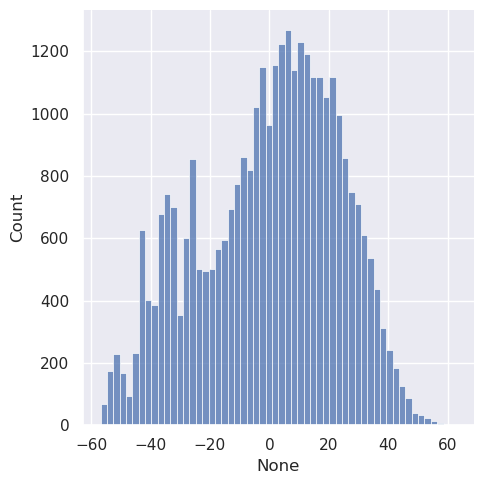

In [41]:
sns.displot(x=subgenre_lm.resid)

In [42]:
sm.stats.anova_lm(subgenre_lm)

,df,sum_sq,mean_sq,F,PR(>F)
C(playlist_subgenre),23.0,2.474062e+06,107567.917241,195.850965,0.0
Residual,32809.0,1.801980e+07,549.233531,NaN,NaN


Subgenre also seems a significant predictor of popularity.

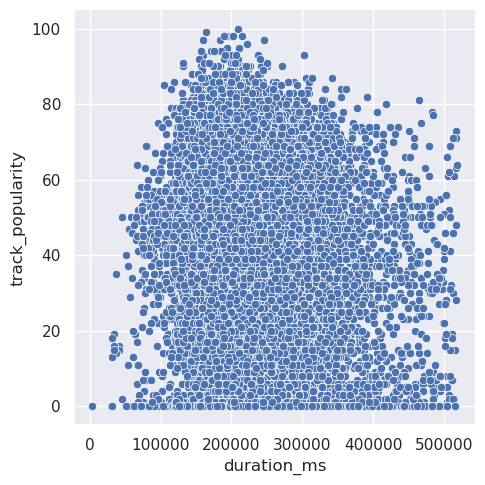

In [43]:
sns.relplot(x='duration_ms',y='track_popularity',data=spotify)

<Axes: xlabel='duration_ms', ylabel='track_popularity'>

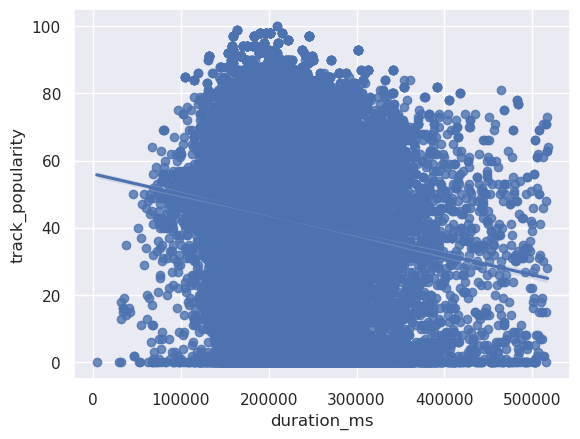

In [44]:
sns.regplot(x='duration_ms',y='track_popularity',data=spotify)

In [45]:
results = smf.ols('track_popularity ~ duration_ms',data = spotify).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       track_popularity   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     692.1
Date:                Thu, 30 Apr 2026   Prob (F-statistic):          5.84e-151
Time:                        09:15:14   Log-Likelihood:            -1.5191e+05
No. Observations:               32833   AIC:                         3.038e+05
Df Residuals:                   32831   BIC:                         3.038e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      56.0241      0.533    105.165      0.000      54.980      57.068
duration_ms     -6e-05   2.28e-06    -26.307      0.000   -6.45e-05   -5.55e-05
==============================================================================
Omnibus:                     5224.720   Durbin-Watson:                   1.103
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1413.759
Skew:                          -0.217   Prob(JB):                    1.01e-307
Kurtosis:                       2.080   Cond. No.                     9.12e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.12e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [46]:
spotify['log10popularity'] = np.log10(spotify.loc[spotify["track_popularity"] > 0, "track_popularity"])

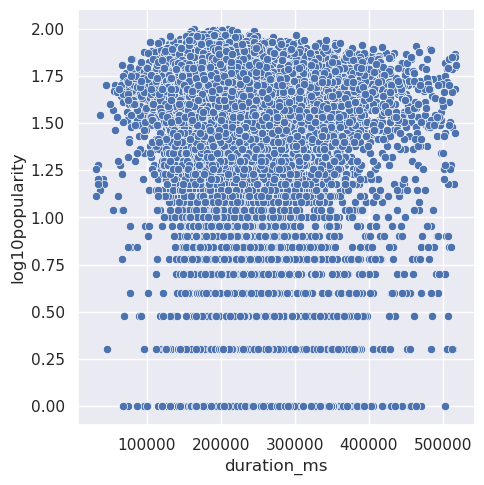

In [47]:
sns.relplot(x='duration_ms',y='log10popularity',data=spotify)

<Axes: xlabel='duration_ms', ylabel='log10popularity'>

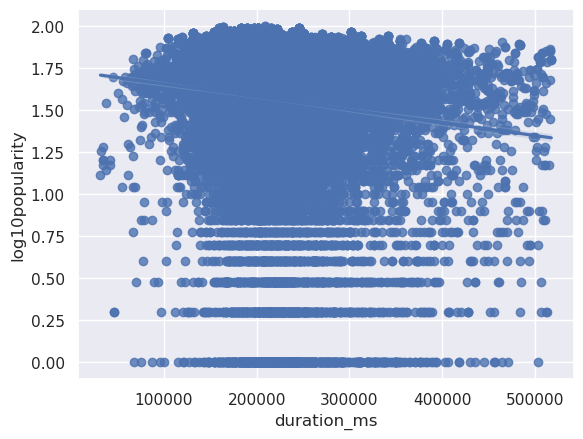

In [48]:
sns.regplot(x='duration_ms',y='log10popularity',data=spotify)

In [49]:
results = smf.ols('log10popularity~ duration_ms',data = spotify).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        log10popularity   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     407.7
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           4.60e-90
Time:                        09:15:17   Log-Likelihood:                -14187.
No. Observations:               30130   AIC:                         2.838e+04
Df Residuals:                   30128   BIC:                         2.839e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       1.7333      0.009    197.001      0.000       1.716       1.751
duration_ms -7.674e-07    3.8e-08    -20.191      0.000   -8.42e-07   -6.93e-07
==============================================================================
Omnibus:                    12859.161   Durbin-Watson:                   1.454
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            52918.431
Skew:                          -2.148   Prob(JB):                         0.00
Kurtosis:                       7.868   Cond. No.                     9.12e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.12e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [50]:
stats.pearsonr(spotify['duration_ms'],spotify['track_popularity'])

PearsonRResult(statistic=np.float64(-0.14368234955875347), pvalue=np.float64(5.8411546526753045e-151))

In [51]:
stats.spearmanr(spotify['duration_ms'],spotify['track_popularity'])

SignificanceResult(statistic=np.float64(-0.12074073756011558), pvalue=np.float64(7.32492844129413e-107))